# App Test Notebook — Champion Model Loading and Forecast Logic

This notebook prepares and tests the Python logic for the Streamlit application.

The goal is to load the champion model selected in Notebook 04, verify that it can generate predictions using the saved feature structure, review the logged MLflow experiments, and prepare the main logic that will later be moved into `app.py`.

This notebook does not retrain any models. It focuses on model loading, prediction testing, visualization, and app-ready logic.

# 1. Environment Setup

The required libraries for model loading, data handling, visualization, and app testing are imported.

In [2]:
# Core libraries
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Environment setup completed.")

Environment setup completed.


# 2. Project Paths

The project paths are defined relative to the current notebook location.

The saved model files are stored in the project-level `models` folder, and the processed dataset is stored in the project-level `data/processed` folder.

In [5]:
# Define project paths

PROJECT_ROOT = os.path.abspath(os.getcwd())

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

CHAMPION_MODEL_PATH = os.path.join(MODELS_DIR, "champion_model_random_forest.pkl")
FEATURE_COLUMNS_PATH = os.path.join(MODELS_DIR, "feature_columns.json")
METADATA_PATH = os.path.join(MODELS_DIR, "champion_model_metadata.json")
TEST_PREDICTIONS_PATH = os.path.join(MODELS_DIR, "champion_model_test_predictions.csv")

FEATURE_DATA_PATH = os.path.join(PROCESSED_DATA_DIR, "feature_engineered_timeseries.csv")

print("Current working directory:", os.getcwd())
print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

Current working directory: n:\-LEARNING\--Portfolio\time-series-forecasting-project
Project root: n:\-LEARNING\--Portfolio\time-series-forecasting-project
Models directory: n:\-LEARNING\--Portfolio\time-series-forecasting-project\models
Processed data directory: n:\-LEARNING\--Portfolio\time-series-forecasting-project\data\processed


In [6]:
# Check that required files exist

required_files = {
    "Champion model": CHAMPION_MODEL_PATH,
    "Feature columns": FEATURE_COLUMNS_PATH,
    "Metadata": METADATA_PATH,
    "Test predictions": TEST_PREDICTIONS_PATH,
    "Feature-engineered data": FEATURE_DATA_PATH
}

for file_name, file_path in required_files.items():
    print(f"{file_name}: {os.path.exists(file_path)}")

Champion model: True
Feature columns: True
Metadata: True
Test predictions: True
Feature-engineered data: True


# 3. Load Champion Model Files

The saved champion model and supporting files are loaded from the project-level `models` folder.
These files were created in Notebook 04 and are used here to verify that the model can be reused without retraining.

In [7]:
# Load champion model and supporting files

champion_model = joblib.load(CHAMPION_MODEL_PATH)

with open(FEATURE_COLUMNS_PATH, "r") as f:
    feature_columns = json.load(f)

with open(METADATA_PATH, "r") as f:
    champion_metadata = json.load(f)

test_predictions_df = pd.read_csv(
    TEST_PREDICTIONS_PATH,
    parse_dates=["date"]
)

print("Champion model and supporting files loaded successfully.")
print("Model type:", type(champion_model))
print("Number of feature columns:", len(feature_columns))
print("Test predictions shape:", test_predictions_df.shape)

Champion model and supporting files loaded successfully.
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Number of feature columns: 23
Test predictions shape: (90, 3)


In [8]:
# Review champion model metadata

print("Champion model metadata:")
print("-" * 40)

for key, value in champion_metadata.items():
    print(f"{key}: {value}")

Champion model metadata:
----------------------------------------
champion_model_name: Random Forest Tuned
model_file: champion_model_random_forest.pkl
feature_columns_file: feature_columns.json
main_metric: RMSE
champion_rmse: 138.01
train_period: {'start': '2013-02-01', 'end': '2013-12-31'}
test_period: {'start': '2014-01-01', 'end': '2014-03-31'}
feature_count: 23
parameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}


# 4. Load Feature-Engineered Dataset

The feature-engineered dataset is loaded to test whether the saved champion model can generate predictions using the same feature structure that was used during training.
This dataset contains the target variable, date column, and engineered features such as calendar, lag, rolling, oil, and holiday features.

In [9]:
# Load the feature-engineered dataset

feature_df = pd.read_csv(
    FEATURE_DATA_PATH,
    parse_dates=["date"]
)

print("Feature-engineered dataset loaded successfully.")
print("Shape:", feature_df.shape)

display(feature_df.head())
display(feature_df.tail())

Feature-engineered dataset loaded successfully.
Shape: (424, 25)


,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
0,2013-02-01,401.0,2013,2,1,4,1,5,0,1,0,282.0,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.46,97.65,96.378571,0,0,0
1,2013-02-02,775.0,2013,2,2,5,1,5,1,0,0,401.0,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,97.46,96.708571,0,0,0
2,2013-02-03,855.0,2013,2,3,6,1,5,1,0,0,775.0,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,97.46,97.038571,0,0,0
3,2013-02-04,411.0,2013,2,4,0,1,6,0,0,0,855.0,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,96.21,97.46,97.368571,0,0,0
4,2013-02-05,272.0,2013,2,5,1,1,6,0,0,0,411.0,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.68,96.21,97.405714,0,0,0


,date,unit_sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_price_interpolated,oil_lag_1,oil_rolling_7d_mean,is_national_holiday,is_regional_holiday,is_local_holiday
419,2014-03-27,328.0,2014,3,27,3,1,13,0,0,0,432.0,139.0,254.0,453.0,422.857143,407.285714,449.700000,152.001566,101.25,100.61,99.987143,0,0,0
420,2014-03-28,523.0,2014,3,28,4,1,13,0,0,0,328.0,456.0,243.0,388.0,449.857143,412.571429,445.533333,101.609430,101.73,101.25,100.211429,0,0,0
421,2014-03-29,647.0,2014,3,29,5,1,13,1,0,0,523.0,567.0,535.0,587.0,459.428571,432.571429,450.033333,105.370548,101.73,101.73,100.462857,0,0,0
422,2014-03-30,599.0,2014,3,30,6,1,13,1,0,0,647.0,603.0,726.0,346.0,470.857143,440.571429,452.033333,122.007416,101.73,101.73,100.714286,0,0,0
423,2014-03-31,415.0,2014,3,31,0,1,14,0,0,1,599.0,371.0,285.0,714.0,470.285714,431.500000,460.466667,121.292641,101.57,101.73,100.965714,0,0,0


# 5. Verify Feature Compatibility

The saved feature column list is compared with the columns in the feature-engineered dataset.

This check ensures that the app will pass the correct inputs to the champion model in the same order used during training.

In [11]:
# Verify that all saved feature columns exist in the dataset

missing_features = [
    col for col in feature_columns
    if col not in feature_df.columns
]

extra_columns = [
    col for col in feature_df.columns
    if col not in feature_columns + ["date", "unit_sales"]
]

print("Number of saved feature columns:", len(feature_columns))
print("Missing features:", missing_features)
print("Extra non-model columns:", extra_columns)

if len(missing_features) == 0:
    print("Feature compatibility check passed.")
else:
    print("Feature compatibility check failed.")

Number of saved feature columns: 23
Missing features: []
Extra non-model columns: []
Feature compatibility check passed.


# 6. Test Champion Model Predictions

The saved champion model is tested on the same January–March 2014 test period.
The goal is to confirm that the saved model, saved feature column list, and feature-engineered dataset work together correctly.

In [12]:
# Define the test period used in the previous modeling notebooks

TEST_START = "2014-01-01"
TEST_END = "2014-03-31"

test_df = feature_df[
    (feature_df["date"] >= TEST_START) &
    (feature_df["date"] <= TEST_END)
].copy()

X_test_app = test_df[feature_columns].copy()
y_test_app = test_df["unit_sales"].copy()

print("App test period:")
print(test_df["date"].min(), "to", test_df["date"].max())

print("\nX_test_app shape:", X_test_app.shape)
print("y_test_app shape:", y_test_app.shape)

App test period:
2014-01-01 00:00:00 to 2014-03-31 00:00:00

X_test_app shape: (90, 23)
y_test_app shape: (90,)


In [13]:
# Generate predictions with the loaded champion model

app_predictions = champion_model.predict(X_test_app)
app_predictions = np.clip(app_predictions, 0, None)

app_prediction_check_df = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_unit_sales": y_test_app.values,
    "predicted_unit_sales": app_predictions
})

display(app_prediction_check_df.head())

,date,actual_unit_sales,predicted_unit_sales
0,2014-01-01,512.5,433.035244
1,2014-01-02,589.0,409.539274
2,2014-01-03,474.0,410.836854
3,2014-01-04,767.0,682.804836
4,2014-01-05,1203.0,767.780643


In [14]:
# Compare newly generated predictions with saved predictions from Notebook 04

comparison_check = pd.DataFrame({
    "date": app_prediction_check_df["date"],
    "new_prediction": app_prediction_check_df["predicted_unit_sales"],
    "saved_prediction": test_predictions_df["predicted_unit_sales"]
})

comparison_check["absolute_difference"] = (
    comparison_check["new_prediction"] - comparison_check["saved_prediction"]
).abs()

display(comparison_check.head())

print("Maximum absolute prediction difference:")
print(comparison_check["absolute_difference"].max())

,date,new_prediction,saved_prediction,absolute_difference
0,2014-01-01,433.035244,433.035244,5.684342e-14
1,2014-01-02,409.539274,409.539274,5.684342e-14
2,2014-01-03,410.836854,410.836854,1.136868e-13
3,2014-01-04,682.804836,682.804836,2.273737e-13
4,2014-01-05,767.780643,767.780643,1.136868e-13


Maximum absolute prediction difference:
2.2737367544323206e-13


The loaded champion model successfully reproduced the saved test-period predictions from Notebook 04.
The maximum absolute difference is effectively zero, which confirms that the saved model, saved feature list, and feature-engineered dataset are compatible.

# 7. Build App-Ready Prediction Function

A reusable prediction function is created to prepare model inputs and generate predictions.
This function will later be adapted for the Streamlit application.

In [15]:
# Define an app-ready prediction function

def generate_predictions(input_df, model, feature_cols):
    """
    Generate predictions using a trained model and a saved feature column list.

    Parameters
    ----------
    input_df : pandas.DataFrame
        Input dataframe containing the required feature columns.
    model : trained model object
        Loaded champion model.
    feature_cols : list
        List of feature columns used during model training.

    Returns
    -------
    pandas.DataFrame
        Dataframe with date, actual values if available, and predicted unit sales.
    """
    missing_cols = [
        col for col in feature_cols
        if col not in input_df.columns
    ]

    if missing_cols:
        raise ValueError(f"Missing required feature columns: {missing_cols}")

    X_input = input_df[feature_cols].copy()

    predictions = model.predict(X_input)
    predictions = np.clip(predictions, 0, None)

    output_df = pd.DataFrame({
        "date": input_df["date"].values,
        "predicted_unit_sales": predictions
    })

    if "unit_sales" in input_df.columns:
        output_df["actual_unit_sales"] = input_df["unit_sales"].values
        output_df = output_df[
            ["date", "actual_unit_sales", "predicted_unit_sales"]
        ]

    return output_df

In [16]:
# Test the app-ready prediction function

function_test_predictions_df = generate_predictions(
    input_df=test_df,
    model=champion_model,
    feature_cols=feature_columns
)

display(function_test_predictions_df.head())

print("Function output shape:", function_test_predictions_df.shape)

,date,actual_unit_sales,predicted_unit_sales
0,2014-01-01,512.5,433.035244
1,2014-01-02,589.0,409.539274
2,2014-01-03,474.0,410.836854
3,2014-01-04,767.0,682.804836
4,2014-01-05,1203.0,767.780643


Function output shape: (90, 3)


# 8. Visualize Actual vs Predicted Results

The saved champion model predictions are visualized against the actual test-period sales values.
This chart will later be adapted for the Streamlit application to show model performance in a user-friendly way.

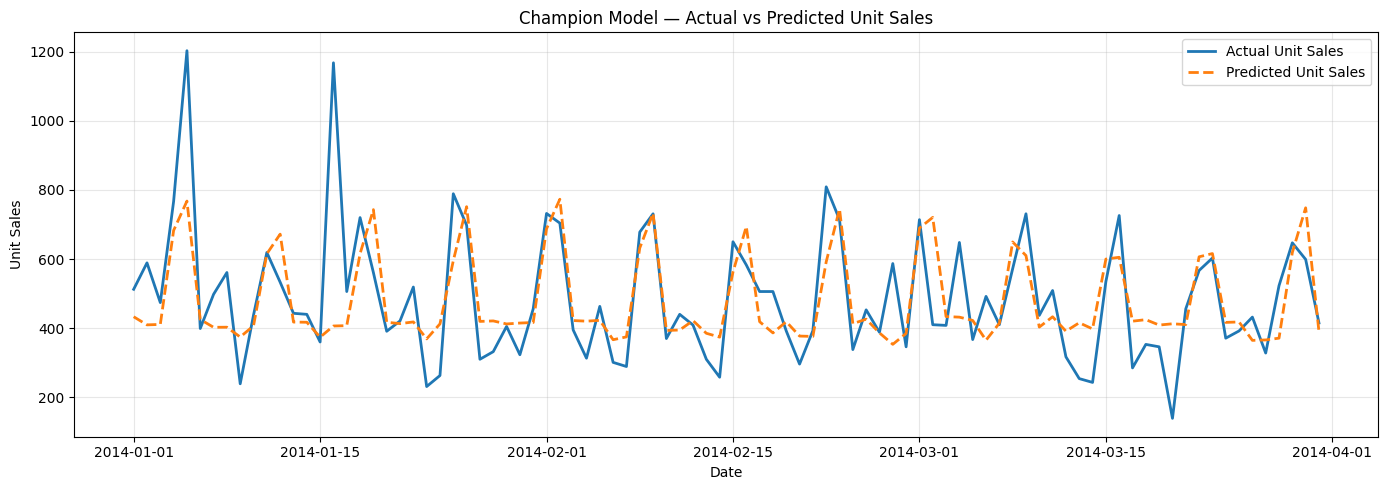

In [17]:
# Plot actual vs predicted unit sales for the test period

plt.figure(figsize=(14, 5))

plt.plot(
    function_test_predictions_df["date"],
    function_test_predictions_df["actual_unit_sales"],
    label="Actual Unit Sales",
    linewidth=2
)

plt.plot(
    function_test_predictions_df["date"],
    function_test_predictions_df["predicted_unit_sales"],
    label="Predicted Unit Sales",
    linewidth=2,
    linestyle="--"
)

plt.title("Champion Model — Actual vs Predicted Unit Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart confirms that the loaded champion model can generate app-ready predictions for the test period.
The model captures the general recurring sales pattern, but it smooths some extreme demand spikes. This behavior is consistent with the evaluation results from Notebook 04.

# 9. Prepare Model Summary for the App

A compact model summary is prepared from the saved metadata.
This information can be displayed in the Streamlit app to explain which model is being used, what metric was used for selection, and which train/test periods were used.

In [18]:
# Prepare model summary for the app

model_summary = {
    "Champion Model": champion_metadata["champion_model_name"],
    "Main Metric": champion_metadata["main_metric"],
    "Champion RMSE": champion_metadata["champion_rmse"],
    "Train Period": f"{champion_metadata['train_period']['start']} to {champion_metadata['train_period']['end']}",
    "Test Period": f"{champion_metadata['test_period']['start']} to {champion_metadata['test_period']['end']}",
    "Feature Count": champion_metadata["feature_count"],
    "Model File": champion_metadata["model_file"]
}

model_summary_df = pd.DataFrame(
    model_summary.items(),
    columns=["Item", "Value"]
)

display(model_summary_df)

,Item,Value
0,Champion Model,Random Forest Tuned
1,Main Metric,RMSE
2,Champion RMSE,138.01
3,Train Period,2013-02-01 to 2013-12-31
4,Test Period,2014-01-01 to 2014-03-31
5,Feature Count,23
6,Model File,champion_model_random_forest.pkl


# 10. Prepare Performance Metrics for the App

The champion model performance metrics are prepared in a compact format.
These values can later be displayed as KPI cards in the Streamlit application.

In [19]:
# Calculate app-ready performance metrics

mae_app = np.mean(
    np.abs(
        function_test_predictions_df["actual_unit_sales"] -
        function_test_predictions_df["predicted_unit_sales"]
    )
)

rmse_app = np.sqrt(
    np.mean(
        (
            function_test_predictions_df["actual_unit_sales"] -
            function_test_predictions_df["predicted_unit_sales"]
        ) ** 2
    )
)

mape_app = np.mean(
    np.abs(
        (
            function_test_predictions_df["actual_unit_sales"] -
            function_test_predictions_df["predicted_unit_sales"]
        ) / function_test_predictions_df["actual_unit_sales"]
    )
) * 100

r2_app = 1 - (
    np.sum(
        (
            function_test_predictions_df["actual_unit_sales"] -
            function_test_predictions_df["predicted_unit_sales"]
        ) ** 2
    )
    / np.sum(
        (
            function_test_predictions_df["actual_unit_sales"] -
            function_test_predictions_df["actual_unit_sales"].mean()
        ) ** 2
    )
)

app_metrics = {
    "MAE": round(mae_app, 2),
    "RMSE": round(rmse_app, 2),
    "MAPE": round(mape_app, 2),
    "R2": round(r2_app, 4)
}

app_metrics_df = pd.DataFrame(
    app_metrics.items(),
    columns=["Metric", "Value"]
)

display(app_metrics_df)

,Metric,Value
0,MAE,93.1400
1,RMSE,138.0100
2,MAPE,21.2900
3,R2,0.4339


# 11. Prepare Business Interpretation for the App

A short business interpretation is prepared for the Streamlit app.
This text explains the champion model result in simple, user-friendly language.

In [20]:
# Prepare app-ready business interpretation text

business_interpretation = """
The champion model is a HyperOpt-tuned Random Forest model.

It was selected because it achieved the lowest RMSE among the tested statistical, machine learning, and advanced LSTM models. The model captures the recurring sales pattern reasonably well, but it still smooths some extreme demand spikes.

This means the model is useful for understanding expected sales patterns and supporting planning decisions, but very sharp peaks should still be interpreted with caution.
"""

print(business_interpretation)


The champion model is a HyperOpt-tuned Random Forest model.

It was selected because it achieved the lowest RMSE among the tested statistical, machine learning, and advanced LSTM models. The model captures the recurring sales pattern reasonably well, but it still smooths some extreme demand spikes.

This means the model is useful for understanding expected sales patterns and supporting planning decisions, but very sharp peaks should still be interpreted with caution.



# 12. Prepare Streamlit App Structure

The tested notebook logic is translated into a Streamlit app structure.
The future `app.py` file should load the saved champion model, load the required metadata and feature columns, generate predictions, and display model performance in a user-friendly format.

In [1]:
# Define the final Streamlit app structure

app_structure = [
    "1. Import required libraries",
    "2. Define project paths",
    "3. Load champion model, feature columns, metadata, and test predictions",
    "4. Load the feature-engineered dataset",
    "5. Define reusable prediction and metric functions",
    "6. Add sidebar controls for cutoff date, forecast horizon, history window, and actual-sales comparison",
    "7. Generate a forecast simulation for the next available days after the selected cutoff date",
    "8. Display planning KPIs: total forecasted sales, average daily forecast, peak forecast day, peak forecasted sales, and demand level",
    "9. Visualize recent historical sales, cutoff date, and predicted sales after cutoff",
    "10. Display the forecast table and CSV download option",
    "11. Add planning interpretation for the selected forecast period",
    "12. Provide technical model validation and champion model details in expandable sections"
]

for step in app_structure:
    print(step)

1. Import required libraries
2. Define project paths
3. Load champion model, feature columns, metadata, and test predictions
4. Load the feature-engineered dataset
5. Define reusable prediction and metric functions
6. Add sidebar controls for cutoff date, forecast horizon, history window, and actual-sales comparison
7. Generate a forecast simulation for the next available days after the selected cutoff date
8. Display planning KPIs: total forecasted sales, average daily forecast, peak forecast day, peak forecasted sales, and demand level
9. Visualize recent historical sales, cutoff date, and predicted sales after cutoff
10. Display the forecast table and CSV download option
11. Add planning interpretation for the selected forecast period
12. Provide technical model validation and champion model details in expandable sections


# 13. Run the Streamlit App

The tested notebook logic was moved into `app.py`.

The Streamlit app was designed as an interactive sales forecast planning prototype for a small grocery store manager. The user selects a cutoff date and a forecast horizon in the sidebar, and the app simulates expected sales for the next available days after the selected cutoff date.

The app displays planning-oriented outputs, including total forecasted sales, average daily forecast, peak forecast day, peak forecasted sales, forecast demand level, a forecast chart, and a downloadable forecast table.

To run the Streamlit application locally, open a terminal from the project root and run:

```powershell
& "d:\-PROJECTS\venvs\time_series_forecasting_win_venv\Scripts\python.exe" -m streamlit run app.py

After the server starts, open:

http://localhost:8501

# 14. Final Notebook Summary

This notebook tested the app-ready logic for the Streamlit forecasting application.
The saved champion model from Notebook 04 was loaded successfully together with the saved feature column list, model metadata, and test-period predictions. The feature-engineered dataset was loaded and checked for compatibility with the saved model feature structure.
The loaded champion model reproduced the saved test-period predictions from Notebook 04 with an effectively zero difference, confirming that the saved model pipeline is reusable.

A reusable prediction function was created and tested. The notebook also prepared app-ready outputs, including prediction results, performance metrics, chart logic, model metadata, and business interpretation.

The final Streamlit app was created in `app.py` and tested locally. The app is designed as a sales forecast planning prototype for a small grocery store manager. It uses sidebar controls for cutoff date, forecast horizon, recent history window, and optional actual-sales comparison.
The app provides planning-oriented outputs such as total forecasted sales, average daily forecast, peak forecast day, peak forecasted sales, forecast demand level, a forecast chart, a forecast table, and a CSV download option.

Technical model validation and champion model details are available in expandable sections, keeping the main interface focused on business planning.
This confirms that the model loading, prediction logic, and interactive Streamlit app are ready for the final project application stage.